In [1]:
import pandas as pd

In [2]:
pd.read_csv('cds_data.csv')

,Date,Country,Market,Is_EM,VIX,Debt_to_GDP,CDS_Spread
0,2018-01-01,USA,DM,0,15.5,105.2,16.5
1,2018-01-01,Germany,DM,0,15.5,65.4,12.2
2,2018-01-01,Brazil,EM,1,15.5,75.3,185.4
3,2018-01-01,Turkey,EM,1,15.5,30.2,210.1
4,2018-01-01,South Africa,EM,1,15.5,56.1,170.8
5,2019-01-01,USA,DM,0,18.2,106.1,17.1
6,2019-01-01,Germany,DM,0,18.2,64.2,12.8
7,2019-01-01,Brazil,EM,1,18.2,77.1,215.3
8,2019-01-01,Turkey,EM,1,18.2,32.4,260.5
9,2019-01-01,South Africa,EM,1,18.2,58.3,205.2


--- Implied Probability of Default (Sample) ---
        Date Country  CDS_Spread  Hazard_Rate     PD_1Y     PD_5Y
0 2018-01-01  Brazil       185.4     0.030900  0.030427  0.143157
1 2019-01-01  Brazil       215.3     0.035883  0.035247  0.164242
2 2020-01-01  Brazil       450.6     0.075100  0.072349  0.313054
3 2021-01-01  Brazil       230.4     0.038400  0.037672  0.174693
4 2022-01-01  Brazil       290.7     0.048450  0.047295  0.215140

--- Econometric Panel Model Summary ---
                            OLS Regression Results                            
Dep. Variable:             CDS_Spread   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     748.7
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           7.05e-15
Time:                        11:32:15   Log-Likelihood:                -84.515
No. Observations:                  20   A

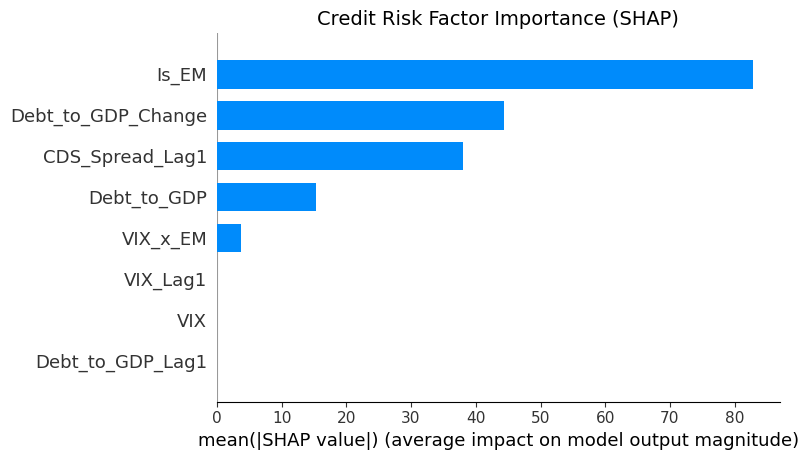

In [3]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
df = pd.read_csv('cds_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Country', 'Date']).reset_index(drop=True)

RECOVERY_RATE = 0.40
LGD = 1.0 - RECOVERY_RATE  
df['Hazard_Rate'] = (df['CDS_Spread'] / 10000.0) / LGD


df['PD_1Y'] = 1.0 - np.exp(-df['Hazard_Rate'] * 1)
df['PD_5Y'] = 1.0 - np.exp(-df['Hazard_Rate'] * 5)

print("--- Implied Probability of Default (Sample) ---")
print(df[['Date', 'Country', 'CDS_Spread', 'Hazard_Rate', 'PD_1Y', 'PD_5Y']].head())


df['Debt_to_GDP_Lag1'] = df.groupby('Country')['Debt_to_GDP'].shift(1)
df['VIX_Lag1'] = df.groupby('Country')['VIX'].shift(1)
df['Debt_to_GDP_Change'] = df.groupby('Country')['Debt_to_GDP'].diff()
df['CDS_Spread_Lag1'] = df.groupby('Country')['CDS_Spread'].shift(1)


df['VIX_x_EM'] = df['VIX'] * df['Is_EM']


df_model = df.dropna().copy()


panel_formula = 'CDS_Spread ~ Debt_to_GDP + VIX + VIX_x_EM + C(Country)'
fe_model = ols(formula=panel_formula, data=df_model).fit(cov_type='HC1')  

print("\n--- Econometric Panel Model Summary ---")
print(fe_model.summary())


feature_cols = [
    'Debt_to_GDP', 'Debt_to_GDP_Lag1', 'Debt_to_GDP_Change',
    'VIX', 'VIX_Lag1', 'Is_EM', 'VIX_x_EM', 'CDS_Spread_Lag1'
]
target_col = 'CDS_Spread'

X = df_model[feature_cols]
y = df_model[target_col]


split_date = df_model['Date'].quantile(0.75)
train_mask = df_model['Date'] < split_date
test_mask = df_model['Date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]


models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=4),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, verbose=-1)
}

print("\n--- Machine Learning Model Performance ---")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"[{name}] RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")



xgb_model = models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)


plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Credit Risk Factor Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()